# Week 8 Lab 1: Data Augmentation & Training Techniques

---

# Change Runtime First
This lab will be slow if you don't use the GPU. Go to Runtime > Change runtime type > GPU

If you want to run on CPU and change run time later, you would need to rerun all the cells from the start.

## Setup: Mount Google Drive and Install Requirements

First, let's mount Google Drive to save our results and set up our environment.

In [6]:
import os
from google.colab import files
import zipfile #making my file a zip (easier than uploading to drive)

uploaded = files.upload() #upload it
zip_path = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_path, 'r') as zip_ref: #unzip it
    zip_ref.extractall("/content/data")  #extract to /content/data

print(os.listdir('/content/data/fer2013'))  #should show train, test
print(os.listdir('/content/data/fer2013/train'))  #should show classes

Saving archive.zip to archive.zip


FileNotFoundError: [Errno 2] No such file or directory: '/content/data/fer2013'

In [ ]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type != 'cuda':
    print("GPU not detected. Go to Runtime > Change runtime type > GPU if you want to use GPU for this session.")
    print("ps. This lab will be slow without GPU")

Using device: cuda


In [ ]:
# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Part 1: Basic Data Augmentation Visualization

Let's start by exploring different augmentation techniques on CIFAR-10 images.

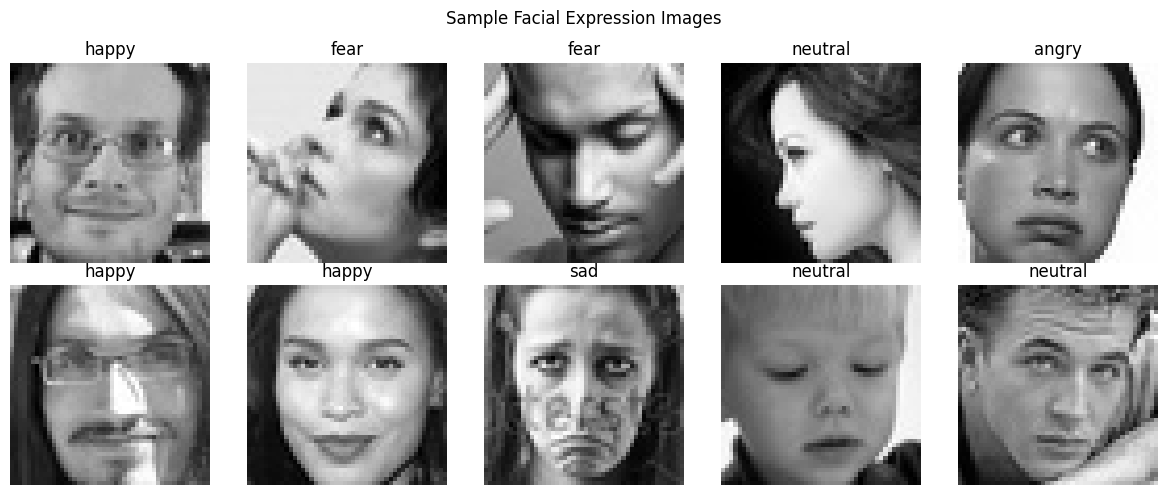

In [ ]:
#load FER2013 dataset..
basic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), #needs to be 1 channel = greyscale
    transforms.ToTensor() #converts to tensors for model
])

viz_dataset = torchvision.datasets.ImageFolder(
    root='/content/data/fer2013/train', #uploading my dataset
    transform=basic_transform
)

classes = viz_dataset.classes #auto reads folder names as class labels

#10 random:
num_samples = 10 #adding 10 random indices so it shows me 10 random samples from all classes
random_indices = random.sample(range(len(viz_dataset)), num_samples)
#otherwise loops through first 10 which are first 10 of 'angry' since alphabetical

# Show original images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i, rnd_index in enumerate(random_indices): #for random indices
    img, label = viz_dataset[rnd_index] #changed i to random index
    img = img.squeeze(0) #removes channel dimension - 1, h, w to h, w (needs 2D arrays for greyscale) - just for plotting not training
    axes[i].imshow(img, cmap = 'gray') #added cmap so correctly displays greyscale as imshow usually RGB
    axes[i].set_title(f'{classes[label]}')
    axes[i].axis('off')
plt.suptitle('Sample Facial Expression Images')
plt.tight_layout()
plt.show()

# Define simple augmentations for training
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), #transforms applied per dataset instatiation
    transforms.Resize((48,48)), #resize to img sizes
    transforms.RandomHorizontalFlip(p=0.5), #so it doesn't have dataset biases like tilting heads
    #transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    #transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
    transforms.Normalize(mean=[0.5], std=[0.5]) #normalise pixel values - more stable training
])

# Validation transform (no augmentation)
#no augmentation like flips etc. in validation set as need to see performance on 'real' data
#whereas training data needs some augmentation to improve generalisation
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48,48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


## Visualisation of Augmentation of data:
to add to test augmentation on training data.

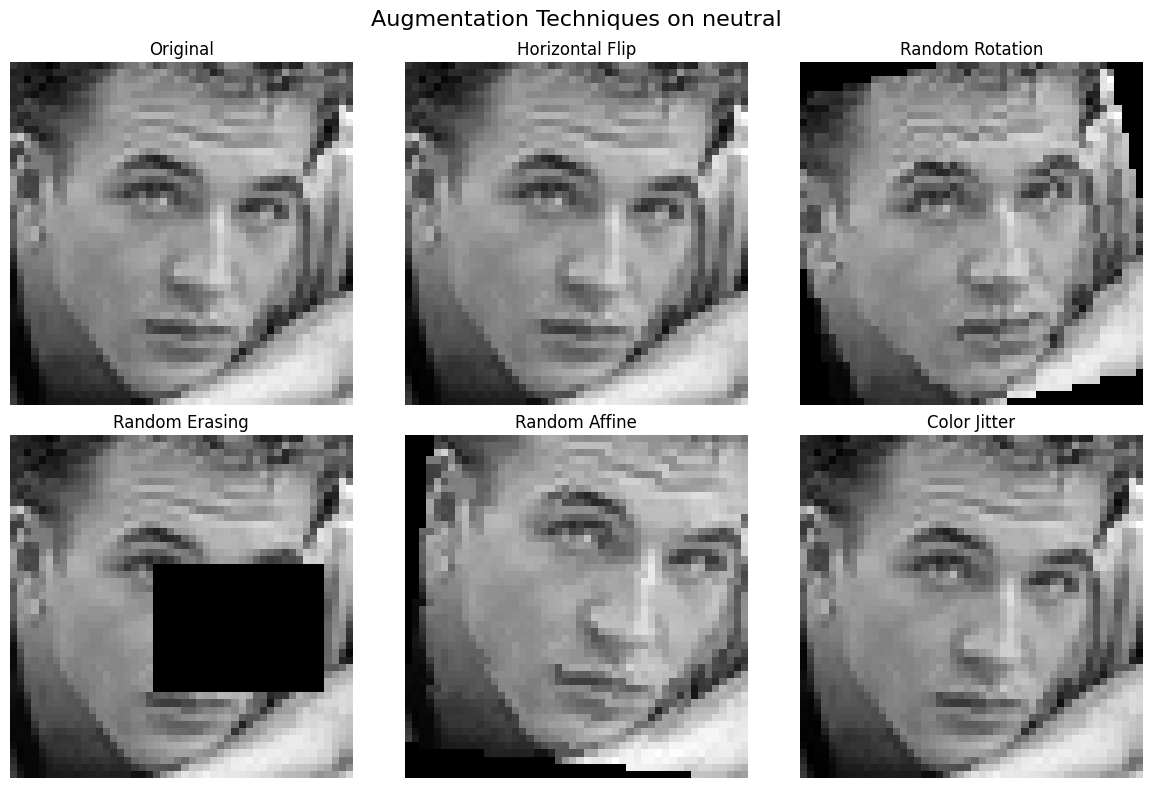

In [ ]:
# Define different augmentation techniques
augmentation_techniques = {
    "Original": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        #adding greyscale and resize for each augmentation for visualisation.
        transforms.Resize((48,48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    "Horizontal Flip": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48,48)),
        transforms.RandomHorizontalFlip(p=0.4),  # Always flip for demo
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    "Random Rotation": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48,48)),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    "Random Erasing": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48,48)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.4, scale=(0.02, 0.2)),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    "Random Affine": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48,48)),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    "Color Jitter": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((48,48)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3), #no need for saturation / hue cos greyscale
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
}

# Visualize augmentations on a single image
fig, axes = plt.subplots(2, 3, figsize=(12, 8)) #changed as i have less pictures so 1x4 and 12x4 to fit better
axes = axes.ravel()

for idx, (name, transform) in enumerate(augmentation_techniques.items()):
    # Reload the dataset with new transform
    dataset = torchvision.datasets.ImageFolder(
        root='/content/data/fer2013/train',
        transform=transform
    )

    img, label = dataset[rnd_index]
    img = img.squeeze(0).numpy() #H,W
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')

plt.suptitle(f'Augmentation Techniques on {classes[label]}', fontsize=16)
plt.tight_layout()
plt.show()

---

# Part 2: Define a Simple CNN Model


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #1 input channel - GREYSCALE
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)  #FER2013 images are 48x48; after pooling twice size is 12x12
        self.fc2 = nn.Linear(128, num_classes) #number of classes: 7
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # Output size: [batch,32,24,24]
        x = self.pool(F.relu(self.conv2(x)))   # Output size: [batch,64,12,12]
        x = x.view(-1, 64 * 12 * 12)             # Flatten feature maps to vector
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                        # No softmax needed with CrossEntropyLoss
        return x

## 2.1: Prepare DataLoaders


In [ ]:
# Load full training and test datasets with transforms
train_dataset = torchvision.datasets.ImageFolder(
    root='/content/data/fer2013/train',
    transform=train_transform
)

test_dataset = torchvision.datasets.ImageFolder(
    root='/content/data/fer2013/test', #needs to be TEST data - try again
    transform=val_transform
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 28709
Test samples: 28709
Batch size: 128


## 2.2: Training Loop (Simplified)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


## 2.3: Run Training and Evaluation


In [ ]:
# Initialize model, loss, optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 45

# Initialize lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    # Train for one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                            optimizer, criterion, device)

    # Evaluate on validation set
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    # Store metrics in lists
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

print("Training complete.")


Epoch 1/45: Train Loss=1.6495, Train Acc=0.3466, Val Loss=1.4693, Val Acc=0.4354
Epoch 2/45: Train Loss=1.4693, Train Acc=0.4345, Val Loss=1.3568, Val Acc=0.4832
Epoch 3/45: Train Loss=1.3833, Train Acc=0.4702, Val Loss=1.2812, Val Acc=0.5225
Epoch 4/45: Train Loss=1.3292, Train Acc=0.4916, Val Loss=1.2258, Val Acc=0.5426
Epoch 5/45: Train Loss=1.2835, Train Acc=0.5133, Val Loss=1.1680, Val Acc=0.5625
Epoch 6/45: Train Loss=1.2471, Train Acc=0.5270, Val Loss=1.1328, Val Acc=0.5757
Epoch 7/45: Train Loss=1.2078, Train Acc=0.5408, Val Loss=1.0759, Val Acc=0.5959
Epoch 8/45: Train Loss=1.1740, Train Acc=0.5509, Val Loss=1.0441, Val Acc=0.6074
Epoch 9/45: Train Loss=1.1455, Train Acc=0.5670, Val Loss=1.0106, Val Acc=0.6275
Epoch 10/45: Train Loss=1.1160, Train Acc=0.5766, Val Loss=0.9713, Val Acc=0.6486
Epoch 11/45: Train Loss=1.0806, Train Acc=0.5906, Val Loss=0.9453, Val Acc=0.6626
Epoch 12/45: Train Loss=1.0554, Train Acc=0.5986, Val Loss=0.9068, Val Acc=0.6762
Epoch 13/45: Train Loss=1

## 2.4: Visualizing Our Results



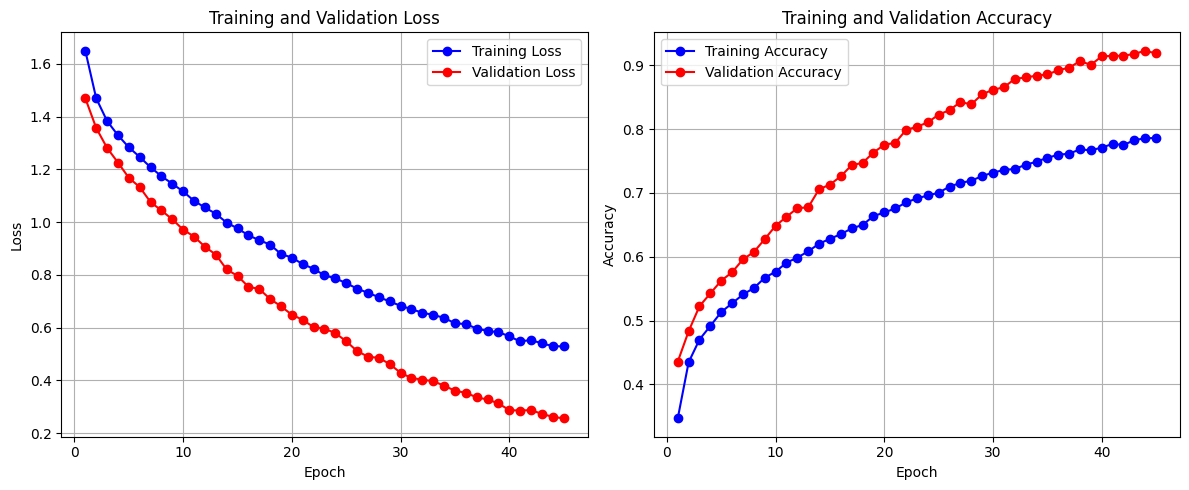

In [ ]:
epochs = range(1, len(train_losses) + 1)  #matches training length

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
plt.plot(epochs, val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


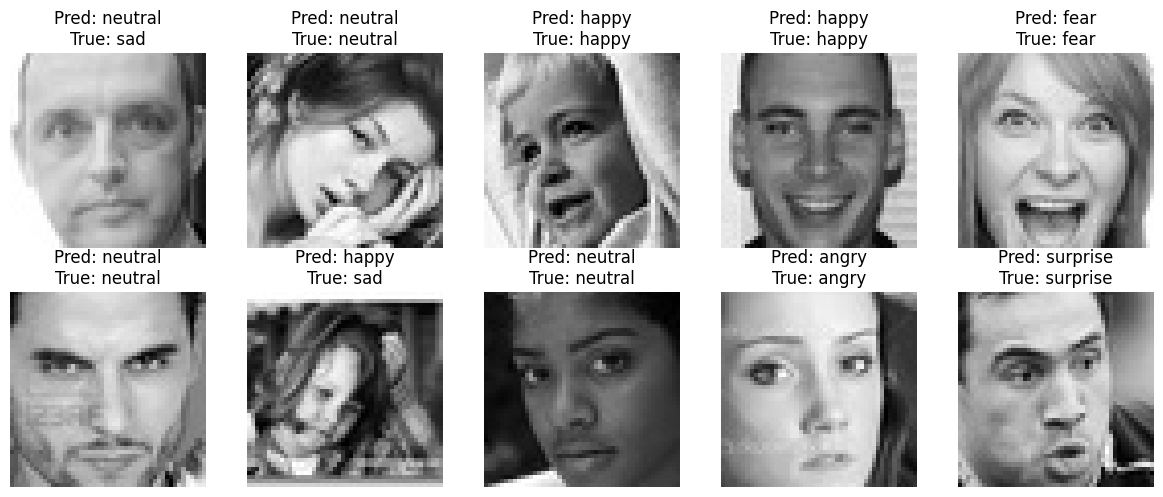

In [ ]:

#TESTING RANDOM PICTURES
# Pick 10 random indices from the whole test dataset
num_samples = 10
random_indices = random.sample(range(len(test_dataset)), num_samples)

model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        img, label = test_dataset[idx]                 # Get image and true label
        input_img = img.unsqueeze(0).to(device)       # Add batch dim and move to device
        output = model(input_img)
        _, pred = torch.max(output, 1)                # Get predicted class

        img_display = img.squeeze(0).cpu()            # Remove channel for grayscale display
        axes[i].imshow(img_display, cmap='gray')
        axes[i].set_title(f"Pred: {classes[pred.item()]}\nTrue: {classes[label]}")
        axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#FINDING WHOLE DATASET ACCURACY - can do it way simpler in training bit..
# Set model to evaluation mode
model.eval()
correct = 0
total = 0

with torch.no_grad():  # no gradients needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = correct / total
print(f"Accuracy on the full test dataset: {accuracy*100:.2f}%")


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

<Figure size 800x800 with 0 Axes>

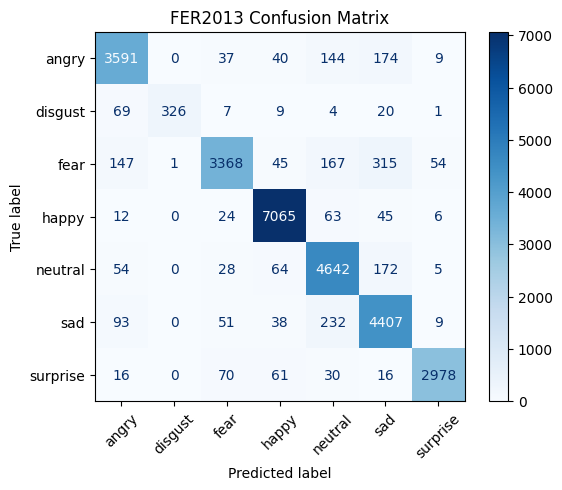

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for img, label in test_dataset:
        input_img = img.unsqueeze(0).to(device)   # Add batch dimension
        output = model(input_img)
        _, pred = torch.max(output, 1)

        all_preds.append(pred.item())
        all_labels.append(label)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)

# Plot it
plt.figure(figsize=(8,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("FER2013 Confusion Matrix")
plt.show()


## Understanding the Training and Validation Graphs

### Loss Curves:
The training loss measures how well the model fits the training data. It should generally decrease as the model learns.
The validation loss tells us how well the model performs on unseen data. Ideally, it should decrease and stay close to the training loss.
If the validation loss starts increasing while training loss keeps decreasing, it may indicate overfitting.


### Accuracy Curves:
Training accuracy shows the percentage of correct predictions on the training set. It typically improves over time.
Validation accuracy measures performance on new data and is a better indicator of how the model will perform in real-world scenarios.
A small gap between training and validation accuracy suggests good generalization. A large gap means the model might be overfitting.


### Signs of Good Training:  

- Both training and validation loss decrease smoothly.  
- Training and validation accuracies both increase and are close to each other.  
- No sudden spikes or erratic behavior in either curve.


### What to Watch For:  

- If training loss decreases but validation loss plateaus or increases, consider adding regularization or data augmentation.  
- If both losses are high, the model may be underfitting—try increasing model capacity or training longer.

Using these graphs, you can monitor your model’s learning progress and make informed decisions about tuning or adjusting your training process.

## 2.5: Save the Trained Model and Training History


### Saving the Model
Saving the model involves storing its learned parameters so you can reuse the trained network later. In PyTorch, this is typically done by saving the model's state dictionary, which contains all the weights and biases. This file is compact and can be loaded into the same model architecture to restore its trained state without retraining. Saving just the state dictionary is preferred over saving the entire model object because it offers more flexibility and compatibility across different environments.

### Saving the Model’s State Dictionary:
This means storing all the learned parameters (weights and biases) of the model after training. This allows you to save the trained model so you can load it later without retraining from scratch. The state dictionary contains only the model parameters, making it lightweight and flexible to use with the same model architecture when you want to perform inference or continue training.

### Saving the Training History
Saving training history means storing information about the model’s performance during training, such as loss and accuracy for each epoch. Keeping this history allows you to analyze how the model learned over time, visualize trends, compare different training runs, and identify issues like overfitting or underfitting. Typically, training history is saved in a simple format like JSON so it can be easily loaded later for plotting or further analysis.

In [ ]:
import json

lab_dir = './results'
os.makedirs(lab_dir, exist_ok=True)  # ensure directory exists

# Save model
model_save_path = os.path.join(lab_dir, 'simplecnn_fer2013.pth')
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Save training history
training_history = {
    'train_loss': train_losses,
    'train_acc': train_accuracies,
    'val_loss': val_losses,
    'val_acc': val_accuracies
}

history_save_path = os.path.join(lab_dir, 'training_history.json')
with open(history_save_path, 'w') as f:
    json.dump(training_history, f)
print(f"Training history saved to {history_save_path}")


Model saved to ./results/simplecnn_fer2013.pth
Training history saved to ./results/training_history.json


In [ ]:
os.listdir()


['.config', 'results', 'drive', 'data', 'archive.zip', 'sample_data']

In [ ]:
!find / -name simplecnn_fer2013.pth 2>/dev/null


/content/results/simplecnn_fer2013.pth


In [ ]:
model.load_state_dict(
    torch.load('/content/results/simplecnn_fer2013.pth')
)


<All keys matched successfully>

In [ ]:
from google.colab import files
files.download('/content/results/simplecnn_fer2013.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##To Load a Saved Model:

In [ ]:
model = SimpleCNN(num_classes=7)
model.load_state_dict(torch.load('/content/results/simplecnn_fer2013.pth'))
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)